Loading BLIP Foundation Model...


Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

Starting Ultimate Denoising Stress Test over 100 objects...



Evaluating: 100%|██████████| 100/100 [05:17<00:00,  3.17s/obj]



                      FINAL DENOISING STRESS TEST ACCURACY                      
Method                    | Std 0.00 | Std 0.25 | Std 0.50 | Std 0.75 | Std 1.00
--------------------------------------------------------------------------------
Raw Attention             |    17.0% |    20.0% |    18.0% |    16.0% |    15.0%
Attention Rollout         |    17.0% |    20.0% |    17.0% |    16.0% |    15.0%
ViT-Grad-CAM              |    18.0% |    17.0% |    18.0% |    17.0% |    20.0%
Attn x Grad (Chefer)      |    69.0% |    68.0% |    68.0% |    61.0% |    66.0%
Deep-Spec (Ours)          |    75.0% |    73.0% |    79.0% |    79.0% |    74.0%

Saved publication-ready line chart to 'denoising_stress_test.png'!


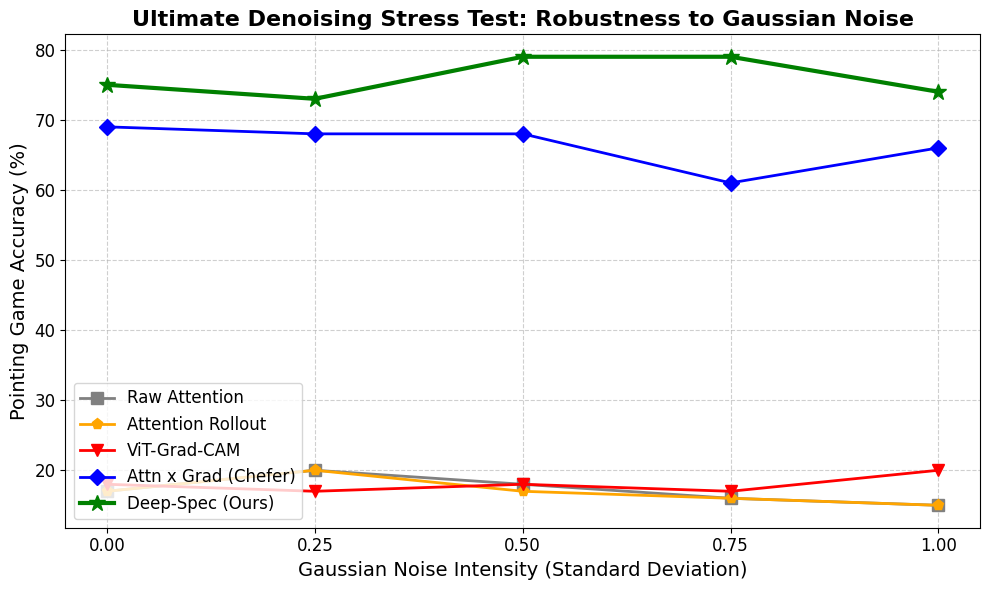

In [ ]:
"""
Deep-Spec Ultimate Denoising Stress Test — BLIP
==================================================================================
Evaluates Pointing Game Accuracy against escalating Gaussian Noise to prove
the Low-Rank Spectral Denoising hypothesis against gradient shattering.
"""

import torch
import numpy as np
from scipy.linalg import eigh
from transformers import BlipProcessor, BlipForImageTextRetrieval
from datasets import load_dataset
from tqdm import tqdm
import warnings
import logging
import requests
import json
import os
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading BLIP Foundation Model...")
MODEL_NAME = "Salesforce/blip-itm-base-coco"
processor = BlipProcessor.from_pretrained(MODEL_NAME)
model = BlipForImageTextRetrieval.from_pretrained(MODEL_NAME).to(device)
model.eval()

GRID_SIZE = 24

ANNOTATION_FILE = "instances_val2017.json"
if not os.path.exists(ANNOTATION_FILE):
    print("Downloading MS-COCO validation bounding boxes...")
    import zipfile
    r = requests.get("http://images.cocodataset.org/annotations/annotations_trainval2017.zip", stream=True)
    with open("annotations.zip", 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    with zipfile.ZipFile("annotations.zip", 'r') as zip_ref:
        zip_ref.extract("annotations/instances_val2017.json", ".")
    os.rename("annotations/instances_val2017.json", ANNOTATION_FILE)
    print("Download complete.")

with open(ANNOTATION_FILE, 'r') as f:
    coco_data = json.load(f)

categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
image_to_objects = {}
for ann in coco_data['annotations']:
    img_id = ann['image_id']
    if img_id not in image_to_objects:
        image_to_objects[img_id] = []
    image_to_objects[img_id].append({
        'category_name': categories[ann['category_id']],
        'bbox': ann['bbox']
    })

dataset = load_dataset("phiyodr/coco2017", split="validation", streaming=True)

methods = ["Raw Attention", "Attention Rollout", "ViT-Grad-CAM", "Attn x Grad (Chefer)", "Deep-Spec (Ours)"]

noise_levels = [0.0, 0.25, 0.5, 0.75, 1.0] # standard Deviations for Gaussian Noise
hits = {m: {lvl: 0 for lvl in noise_levels} for m in methods}
total_evaluated = 0
NUM_EVALS = 100

def extract_all_heatmaps(inputs, valid_indices, tgt_rel):
    heatmaps = {}

    attn_maps = []
    hooks = []
    def hook_fn(module, inp, out):
        attn_maps.append(inp[0].detach().cpu())

    for name, module in model.named_modules():
        if "crossattention.self.dropout" in name:
            hooks.append(module.register_forward_hook(hook_fn))

    with torch.no_grad():
        _ = model(**inputs)

    for h in hooks:
        h.remove()

    all_layers_attn = torch.stack(attn_maps)

    # RAW ATTENTION
    avg_attn = all_layers_attn.mean(dim=(0, 1, 2))
    avg_attn = avg_attn[valid_indices, 1:]
    hm_raw = avg_attn[tgt_rel].max(dim=0).values.reshape(GRID_SIZE, GRID_SIZE)
    hm_raw = hm_raw / (hm_raw.max() + 1e-10)
    heatmaps["Raw Attention"] = hm_raw.numpy()

    # ATTENTION ROLLOUT
    T, I = all_layers_attn.shape[-2], all_layers_attn.shape[-1]
    rollout = torch.eye(T + I)
    for layer_attn in all_layers_attn:
        avg_heads = layer_attn.mean(dim=(0, 1))
        full = torch.zeros((T + I, T + I))
        full[:T, T:] = avg_heads
        full[T:, :T] = avg_heads.T
        full = 0.5 * full + 0.5 * torch.eye(T + I)
        rollout = rollout @ full

    text_to_img_rollout = rollout[:T, T:]
    filtered_rollout = text_to_img_rollout[valid_indices, 1:]
    hm_roll = filtered_rollout[tgt_rel].max(dim=0).values.reshape(GRID_SIZE, GRID_SIZE)
    hm_roll = hm_roll / (hm_roll.max() + 1e-10)
    heatmaps["Attention Rollout"] = hm_roll.numpy()

    # deep-spec
    A_global = all_layers_attn.mean(dim=(0, 1, 2))
    A_global = A_global[valid_indices, 1:]
    A_global = A_global / (A_global.max() + 1e-10)
    W_c = A_global.numpy()

    T_ds, I_ds = W_c.shape
    N = T_ds + I_ds
    W = np.zeros((N, N))
    W[:T_ds, T_ds:] = W_c
    W[T_ds:, :T_ds] = W_c.T
    W = W + 1e-3

    D = np.sum(W, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
    L_sym = np.eye(N) - D_inv_sqrt @ W @ D_inv_sqrt
    _, eigvecs = eigh(L_sym)

    K_components = 5
    V_text = eigvecs[:T_ds, 1:K_components+1]
    V_img = eigvecs[T_ds:, 1:K_components+1]
    denoised_affinity = V_text @ V_img.T

    target_affinity = np.abs(denoised_affinity[tgt_rel, :])
    hm_ds = target_affinity.max(axis=0).reshape(GRID_SIZE, GRID_SIZE)
    hm_ds = (hm_ds - hm_ds.min()) / (hm_ds.max() - hm_ds.min() + 1e-10)
    heatmaps["Deep-Spec (Ours)"] = hm_ds

    # GRADIENT EXTRACTIONS
    activations, gradients = None, None
    attn_maps_grad, grad_maps = [], []

    def forward_hook_gcam(module, inp, out):
        nonlocal activations
        activations = out[0].detach()

    def backward_hook_gcam(module, grad_in, grad_out):
        nonlocal gradients
        gradients = grad_out[0].detach()

    def forward_hook_chefer(module, inp, out):
        attn = inp[0]
        attn_maps_grad.append(attn)
        attn.retain_grad()
        attn.register_hook(lambda g: grad_maps.append(g))

    hooks_grad = []
    target_layer = model.vision_model.encoder.layers[-1]
    hooks_grad.append(target_layer.register_forward_hook(forward_hook_gcam))
    hooks_grad.append(target_layer.register_full_backward_hook(backward_hook_gcam))

    for name, module in model.named_modules():
        if "crossattention.self.dropout" in name:
            hooks_grad.append(module.register_forward_hook(forward_hook_chefer))

    model.zero_grad()
    outputs = model(**inputs)
    itm_score = outputs.itm_score[0, 1]
    itm_score.backward()

    for h in hooks_grad:
        h.remove()

    if gradients is not None and activations is not None:
        weights = gradients.mean(dim=(0, 1))
        cam = (weights * activations).sum(dim=-1).squeeze(0)
        cam = torch.relu(cam)[1:]
        cam = cam.reshape(GRID_SIZE, GRID_SIZE)
        cam = cam / (cam.max() + 1e-10)
        heatmaps["ViT-Grad-CAM"] = cam.detach().cpu().numpy()
    else:
        heatmaps["ViT-Grad-CAM"] = np.zeros((GRID_SIZE, GRID_SIZE))

    if len(attn_maps_grad) > 0 and len(grad_maps) > 0:
        heatmap_chefer = torch.zeros_like(attn_maps_grad[0].mean(dim=(0, 1)))
        for attn, grad in zip(attn_maps_grad, grad_maps):
            heatmap_chefer += (attn * grad).mean(dim=(0, 1))

        heatmap_chefer = heatmap_chefer / len(attn_maps_grad)
        heatmap_chefer = heatmap_chefer[valid_indices, 1:]
        heatmap_chefer = torch.clamp(heatmap_chefer, min=0)

        hm_chefer = heatmap_chefer[tgt_rel].max(dim=0).values.reshape(GRID_SIZE, GRID_SIZE)
        hm_chefer = hm_chefer / (hm_chefer.max() + 1e-10)
        heatmaps["Attn x Grad (Chefer)"] = hm_chefer.detach().cpu().numpy()
    else:
        heatmaps["Attn x Grad (Chefer)"] = np.zeros((GRID_SIZE, GRID_SIZE))

    return heatmaps

print(f"Starting Ultimate Denoising Stress Test over {NUM_EVALS} objects...\n")
iterator = iter(dataset)

with tqdm(total=NUM_EVALS, desc="Evaluating", unit="obj") as pbar:
    while total_evaluated < NUM_EVALS:
        try:
            data = next(iterator)
            image_id = data.get('image_id')

            if image_id not in image_to_objects: continue
            objects = image_to_objects[image_id]

            if 'image' in data and data['image'] is not None:
                image = data['image'].convert("RGB")
            elif 'coco_url' in data:
                response = requests.get(data['coco_url'], timeout=10)
                image = Image.open(BytesIO(response.content)).convert("RGB")
            else: continue

            orig_W, orig_H = image.size

            caption = data['captions'][0] if isinstance(data.get('captions'), list) else data.get('text', "")
            if not caption: continue

            target_noun = None
            for obj in objects:
                if obj['category_name'].lower() in caption.lower():
                    target_noun = obj['category_name']
                    break

            if not target_noun: continue
            all_target_bboxes = [obj['bbox'] for obj in objects if obj['category_name'] == target_noun]

            base_inputs = processor(images=image, text=caption, return_tensors="pt").to(device)
            clean_pixel_values = base_inputs["pixel_values"].clone()

            tokens = processor.tokenizer.convert_ids_to_tokens(base_inputs["input_ids"][0])
            special_ids = processor.tokenizer.all_special_ids
            valid_indices = [i for i, idx in enumerate(base_inputs["input_ids"][0].tolist()) if idx not in special_ids]

            target_indices = []
            for i, t in enumerate(tokens):
                if i in valid_indices:
                    clean_token = t.lower().replace("##", "")
                    if any(word in clean_token or clean_token in word for word in target_noun.lower().split()):
                        target_indices.append(i)

            if not target_indices: continue
            tgt_rel = [valid_indices.index(idx) for idx in target_indices]

            for noise_std in noise_levels:
                inputs = {
                    "input_ids": base_inputs["input_ids"],
                    "attention_mask": base_inputs["attention_mask"]
                }

                if noise_std > 0:
                    noise = torch.randn_like(clean_pixel_values) * noise_std
                    inputs["pixel_values"] = clean_pixel_values + noise
                else:
                    inputs["pixel_values"] = clean_pixel_values

                heatmaps = extract_all_heatmaps(inputs, valid_indices, tgt_rel)
                if heatmaps is None: continue

                for m_name in methods:
                    hm = heatmaps[m_name]
                    if hm.max() == 0: continue

                    max_idx = np.argmax(hm)
                    max_y_patch, max_x_patch = np.unravel_index(max_idx, hm.shape)

                    rel_x = (max_x_patch + 0.5) / GRID_SIZE
                    rel_y = (max_y_patch + 0.5) / GRID_SIZE
                    pixel_x = rel_x * orig_W
                    pixel_y = rel_y * orig_H

                    hit = False
                    for bbox in all_target_bboxes:
                        x_min, y_min, bbox_w, bbox_h = bbox
                        x_max, y_max = x_min + bbox_w, y_min + bbox_h
                        if (x_min <= pixel_x <= x_max) and (y_min <= pixel_y <= y_max):
                            hit = True
                            break

                    if hit:
                        hits[m_name][noise_std] += 1

            total_evaluated += 1
            pbar.update(1)

        except StopIteration:
            break
        except Exception as e:
            continue

print("\n" + "=" * 80)
print(" FINAL DENOISING STRESS TEST ACCURACY ".center(80))
print("=" * 80)
header = f"{'Method':<25} | " + " | ".join([f"Std {std:.2f}" for std in noise_levels])
print(header)
print("-" * 80)
for m_name in methods:
    accs = [f"{(hits[m_name][std] / total_evaluated * 100):.1f}%" for std in noise_levels]
    row = f"{m_name:<25} | " + " | ".join([f"{a:>8}" for a in accs])
    print(row)
print("=" * 80)

# plotting

plt.figure(figsize=(10, 6))

colors = {
    "Raw Attention": "gray",
    "Attention Rollout": "orange",
    "ViT-Grad-CAM": "red",
    "Attn x Grad (Chefer)": "blue",
    "Deep-Spec (Ours)": "green"
}
markers = {
    "Raw Attention": "s",
    "Attention Rollout": "p",
    "ViT-Grad-CAM": "v",
    "Attn x Grad (Chefer)": "D",
    "Deep-Spec (Ours)": "*"
}

for m_name in methods:
    accuracies = [(hits[m_name][std] / total_evaluated) * 100 for std in noise_levels]
    linewidth = 3 if "Deep-Spec" in m_name else 2
    markersize = 12 if "Deep-Spec" in m_name else 8
    plt.plot(noise_levels, accuracies, marker=markers[m_name], color=colors[m_name],
             linewidth=linewidth, markersize=markersize, label=m_name)

plt.title("Ultimate Denoising Stress Test: Robustness to Gaussian Noise", fontsize=16, fontweight='bold')
plt.xlabel("Gaussian Noise Intensity (Standard Deviation)", fontsize=14)
plt.ylabel("Pointing Game Accuracy (%)", fontsize=14)
plt.xticks(noise_levels, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, loc='lower left')

plt.tight_layout()
plt.savefig("denoising_stress_test.png", dpi=300, bbox_inches='tight')
print("\nSaved publication-ready line chart to 'denoising_stress_test.png'!")